In [29]:
import numpy as np
import random
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(42)
random.seed(42)

## Task 3

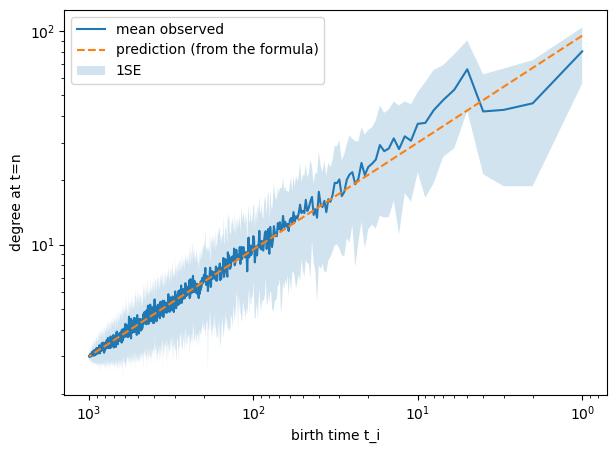

In [28]:
def ensemble_avg_ba(n, m, R=50):
    # R repeats to average the resuts
    degrees_all = np.zeros((R, n), dtype=float)
    for r in range(R):
        G = nx.barabasi_albert_graph(n, m)  # nodes are labeled in order of addition
        degs = np.array([G.degree(i) for i in range(n)])
        degrees_all[r, :] = degs
    mean_deg = degrees_all.mean(axis=0)
    se_deg = degrees_all.std(axis=0)
    return mean_deg, se_deg

# analysis only for final time is sufficient, we can change n to see what will happen in the 'meantime'
n = 1000
m = 3
mean_deg, se_deg = ensemble_avg_ba(n, m, R=50)
t = n
t_i = np.arange(1, n+1)
k_pred = m * np.sqrt(t / t_i)

plt.figure(figsize=(7,5))
plt.loglog(t_i, mean_deg, label='mean observed')
plt.loglog(t_i, k_pred, '--', label='prediction (from the formula)')
plt.fill_between(t_i, mean_deg - se_deg, mean_deg + se_deg, alpha=0.2, label='1SE')
plt.gca().invert_xaxis()
plt.xlabel('birth time t_i')
plt.ylabel('degree at t=n')
plt.legend()
plt.show()



## Task 4

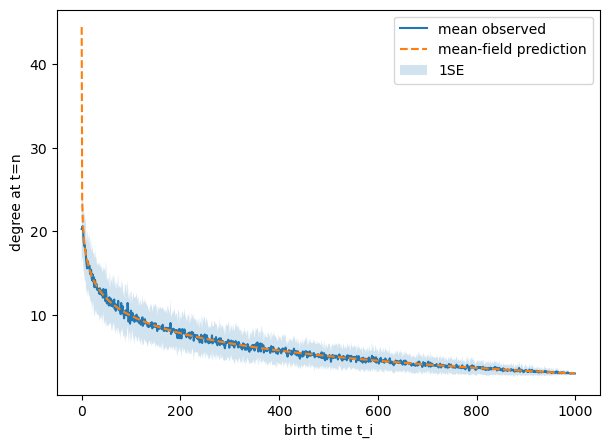

In [38]:
def simulate_random_attachment(n, m, m0=3):
    """Simulate A model: growing network with random attachment."""
    # start with complete graph
    G = nx.complete_graph(m0)
    degrees = np.array([G.degree(i) for i in G.nodes()])
    birth_times = np.arange(m0)  # t_i for initial nodes

    for t in range(m0, n):
        G.add_node(t)
        # choose m distinct targets uniformly at random from existing nodes
        targets = random.sample(list(G.nodes())[:-1], m)
        for target in targets:
            G.add_edge(t, target)
        degrees = np.array([G.degree(i) for i in G.nodes()])
        birth_times = np.append(birth_times, t)

    return degrees, birth_times

def ensemble_avg_random(n, m, m0=3, R=50):
    degrees_all = np.zeros((R, n), dtype=float)
    for r in range(R):
        deg, t_i = simulate_random_attachment(n, m, m0)
        degrees_all[r, :] = deg
    mean_deg = degrees_all.mean(axis=0)
    se_deg = degrees_all.std(axis=0)
    return mean_deg, se_deg, t_i


n = 1000
m = 3
m0 = 3
R = 50
eps = 1e-3

mean_deg, se_deg, t_i = ensemble_avg_random(n, m, m0, R)
t = n 
k_pred = m * np.log(t / (t_i + eps)) + m

plt.figure(figsize=(7,5))
plt.plot(t_i, mean_deg, label='mean observed')
plt.plot(t_i, k_pred, '--', label='mean-field prediction')
plt.fill_between(t_i, mean_deg - se_deg, mean_deg + se_deg, alpha=0.2, label='1SE')
plt.xlabel('birth time t_i')
plt.ylabel('degree at t=n')
plt.legend()
plt.show()

## Task 5

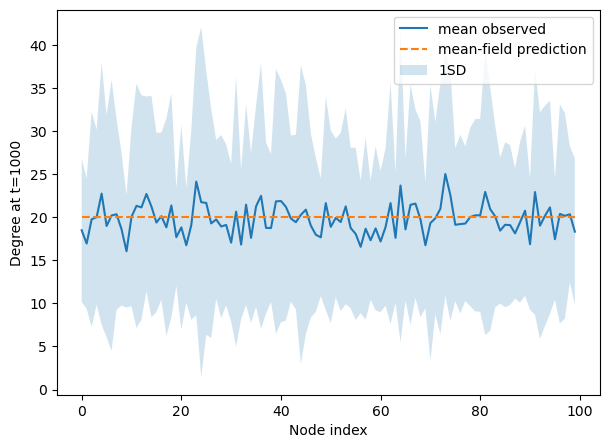

In [40]:
def fixed_size_b_model(N=100, m_steps=1000, R=50):
    # N = number of nodes
    # m_steps = number of edges to add
    mean_deg_all = np.zeros(N)
    se_deg_all = np.zeros(N)
    
    for r in range(R):
        # start with N isolated nodes
        G = nx.empty_graph(N)
        degrees = np.zeros(N)
        stubs = []  # list of node indices repeated by degree (for preferential attachment)
        
        for t in range(m_steps):
            # pick first node uniformly
            u = random.randrange(N)
            # pick second node preferentially
            if stubs:
                v = random.choice(stubs)
            else:
                v = random.randrange(N)
            # avoid self-loop
            if u == v:
                continue
            G.add_edge(u, v)
            degrees[u] += 1
            degrees[v] += 1
            stubs.extend([u, v])
        
        mean_deg_all += degrees
        se_deg_all += degrees**2
    
    mean_deg = mean_deg_all / R
    std_deg = np.sqrt(se_deg_all / R - mean_deg**2)
    return mean_deg, std_deg

# Run simulation
N = 100
m_steps = 1000
R = 50
mean_deg, std_deg = fixed_size_b_model(N, m_steps, R)

# Mean-field prediction: k_i(t) ~ 2/N * t
t = m_steps
k_pred = 2 / N * t * np.ones(N)

# Plot
plt.figure(figsize=(7,5))
plt.plot(range(N), mean_deg, '-', label='mean observed')
plt.plot(range(N), k_pred, '--', label='mean-field prediction')
plt.fill_between(range(N), mean_deg - std_deg, mean_deg + std_deg, alpha=0.2, label='1SD')
plt.xlabel('Node index')
plt.ylabel(f'Degree at t={t}')
plt.legend()
plt.show()

## Task 6

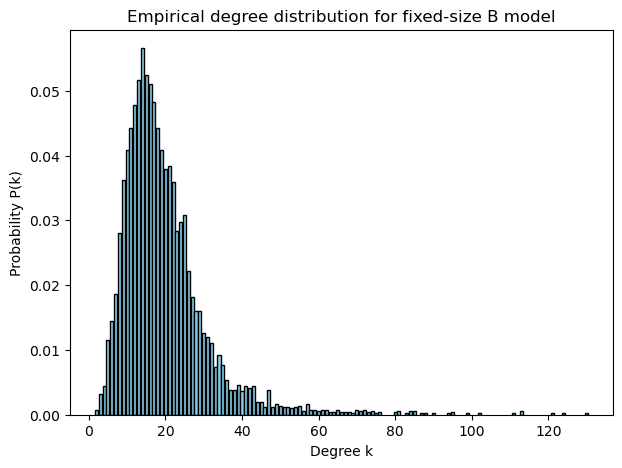

In [42]:
# Empirical degree distribution for model B (fixed-size network with preferential attachment)
# Use the ensemble average approach for robustness

def fixed_size_b_model_degree_distribution(N=100, m_steps=1000, R=50):
    # Collect degrees from R simulations
    all_degrees = []
    for r in range(R):
        # initialize N isolated nodes
        G = nx.empty_graph(N)
        degrees = np.zeros(N)
        stubs = []
        for t in range(m_steps):
            # pick first node uniformly
            u = random.randrange(N)
            # pick second node preferentially
            if stubs:
                v = random.choice(stubs)
            else:
                v = random.randrange(N)
            if u == v:
                continue
            G.add_edge(u, v)
            degrees[u] += 1
            degrees[v] += 1
            stubs.extend([u,v])
        all_degrees.extend(degrees.tolist())
    return np.array(all_degrees)

# Parameters
N = 100
m_steps = 1000
R = 50

# Run simulation
degrees_B = fixed_size_b_model_degree_distribution(N=N, m_steps=m_steps, R=R)

# Compute histogram / empirical degree distribution
degree_values, counts = np.unique(degrees_B, return_counts=True)
P_k = counts / counts.sum()  # normalized

# Plot empirical degree distribution
plt.figure(figsize=(7,5))
plt.bar(degree_values, P_k, width=0.8, color='skyblue', edgecolor='k')
plt.xlabel('Degree k')
plt.ylabel('Probability P(k)')
plt.title('Empirical degree distribution for fixed-size B model')
plt.show()
